In [1]:
# @title Setup Cell (Run First)
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tensorflow==2.16.1 opencv-contrib-python-headless tqdm matplotlib numpy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title Configuration
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, losses, optimizers
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Reduced training scale
IMG_SIZE = 256
CHANNELS = 3
BATCH_SIZE = 8
EPOCHS = 100
TOTAL_IMAGES = 1000
STEPS_PER_EPOCH = TOTAL_IMAGES // BATCH_SIZE
# Add to existing Config Cell
INITIAL_EPOCH = 70  # ⚠️ Set this to your last completed epoch
RESUME_MODE = True  # Set to False for fresh training

# Paths (change these to your preferred locations)
DATA_PATH = "//ADD DRIVE PATH WHERE YOUR DATASET IS LOCATED//"  # Your 1000 CelebA-HQ images
MODEL_PATH = "//ADD DRIVE PATH WHERE MODEL IS TO BE SAVED//"
os.makedirs(MODEL_PATH, exist_ok=True)

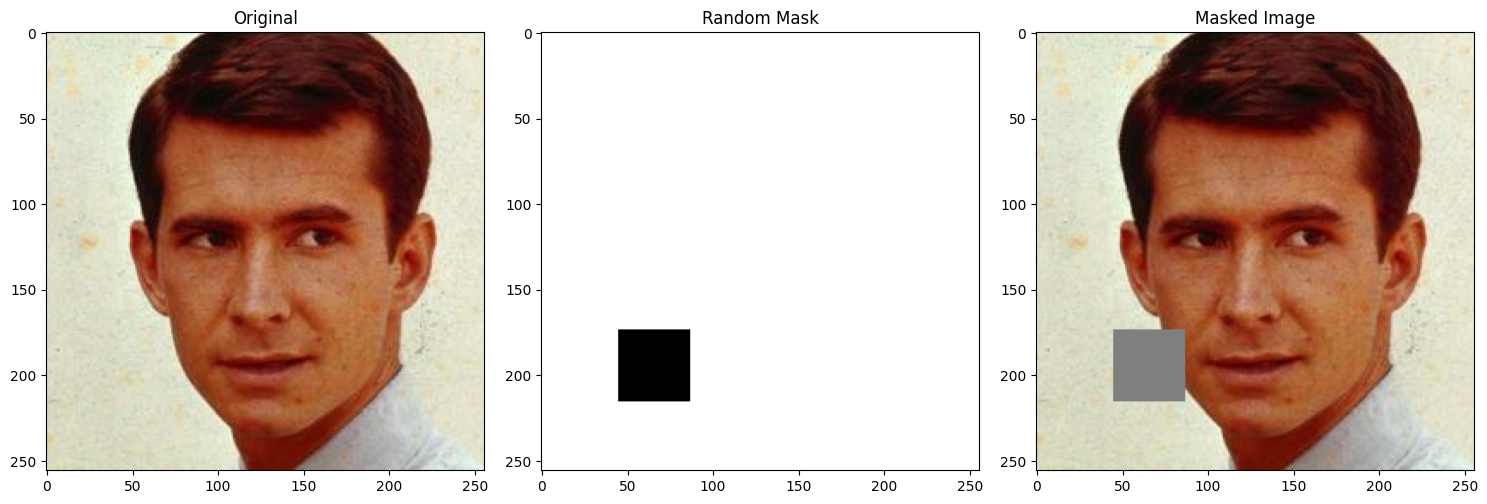

In [ ]:
# @title Data Loading with Random Position Masks
def load_dataset():
    image_paths = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)[:TOTAL_IMAGES]]

    def process_image(img_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = (img - 127.5) / 127.5  # Normalize to [-1,1]
        img = tf.image.random_flip_left_right(img)  # Data augmentation
        return img

    return tf.data.Dataset.from_tensor_slices(image_paths).map(
        process_image, num_parallel_calls=tf.data.AUTOTUNE)

def generate_masks():
    def create_mask():
        mask = np.ones((IMG_SIZE, IMG_SIZE, CHANNELS), dtype=np.float32)

        # Random small rectangle mask (32x32 to 64x64 pixels)
        mask_height = np.random.randint(32, 65)
        mask_width = np.random.randint(32, 65)

        # Random position ensuring it stays within image bounds
        x = np.random.randint(0, IMG_SIZE - mask_width)
        y = np.random.randint(0, IMG_SIZE - mask_height)

        # Apply rectangular mask
        mask[y:y+mask_height, x:x+mask_width] = 0
        return mask

    return tf.data.Dataset.from_tensor_slices([create_mask() for _ in range(TOTAL_IMAGES)])

# Create final dataset
images_ds = load_dataset()
masks_ds = generate_masks()
dataset = tf.data.Dataset.zip((images_ds, masks_ds))
dataset = dataset.map(lambda img, mask: (img, mask, img * mask))
dataset = dataset.shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Visualize sample
sample_img, sample_mask, sample_masked = next(iter(dataset))
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(sample_img[0]*0.5+0.5); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(sample_mask[0], cmap='gray'); plt.title("Random Mask")
plt.subplot(1, 3, 3); plt.imshow(sample_masked[0]*0.5+0.5); plt.title("Masked Image")
plt.tight_layout()
plt.show()

In [3]:
# @title Lightweight Generator (Modified for Faster Training)
def build_generator():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    mask = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    x = layers.Concatenate()([inputs, mask])

    # Simplified architecture
    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Upsampling
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    output = layers.Conv2DTranspose(3, 5, strides=2, padding='same', activation='tanh')(x)

    return Model([inputs, mask], output)

generator = build_generator()
generator.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 6)                │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      9,664 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │    204,928 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    295,168 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    295,040 │ leaky_re_lu_2[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │    204,864 │ re_lu[0][0]       │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 1,016,771 (3.88 MB)

 Trainable params: 1,015,619 (3.87 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [4]:
# @title Efficient Discriminator
def build_discriminator():
    img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    mask = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    x = layers.Concatenate()([img, mask])

    # Lightweight PatchGAN
    x = layers.Conv2D(64, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(1, 4, padding='same')(x)

    return Model([img, mask], x)

discriminator = build_discriminator()
discriminator.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (Concatenate)       │ 6)                │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      6,208 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    131,200 │ leaky_re_lu_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    524,544 │ leaky_re_lu_4[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32, 1) │      4,097 │ leaky_re_lu_5[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 667,585 (2.55 MB)

 Trainable params: 666,817 (2.54 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# @title Training Setup with Enhanced Stability
# ====== LOSS FUNCTIONS ======
cross_entropy = losses.BinaryCrossentropy(from_logits=True)

# ====== OPTIMIZERS (LOWERED LEARNING RATES) ======
g_optimizer = optimizers.Adam(5e-5, beta_1=0.5)  # Reduced from 1e-4
d_optimizer = optimizers.Adam(2e-5, beta_1=0.5)  # Discriminator learns slower

# ====== CHECKPOINT SETUP ======
checkpoint_dir = os.path.join(MODEL_PATH, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

# Initialize models
generator = build_generator()
discriminator = build_discriminator()

# ====== ENHANCED CHECKPOINTING ======
checkpoint = tf.train.Checkpoint(
    generator_optimizer=g_optimizer,
    discriminator_optimizer=d_optimizer,
    generator=generator,
    discriminator=discriminator
)

# ====== RESUME LOGIC ======
if RESUME_MODE:
    latest = tf.train.latest_checkpoint(checkpoint_dir)
    if latest:
        # Load complete training state
        status = checkpoint.restore(latest)
        status.expect_partial()

        # Recover best loss from checkpoint name
        try:
            best_loss = float(latest.split('_gl')[-1].split('_')[0])
        except:
            best_loss = float('inf')

        print(f"✅ Resumed from {latest} (Epoch {INITIAL_EPOCH})")
        print(f"Best loss: {best_loss:.4f}")
    else:
        print("⚠️ No checkpoint found - training from scratch")
        INITIAL_EPOCH = 0
        best_loss = float('inf')
else:
    print("🧹 Starting fresh training")
    INITIAL_EPOCH = 0
    best_loss = float('inf')

# ====== TRAINING STATE ======
patience = 5
wait = 0  # Early stopping counter
current_gd_ratio = 1.0  # Will be updated during training

# ====== GRADIENT PENALTY SETUP ======
def gradient_penalty(real_images, fake_images, masks):
    batch_size = real_images.shape[0]
    alpha = tf.random.uniform([batch_size, 1, 1, 1], 0., 1.)
    interpolates = alpha * real_images + (1-alpha) * fake_images

    with tf.GradientTape() as tape:
        tape.watch(interpolates)
        pred = discriminator([interpolates, masks])
    gradients = tape.gradient(pred, interpolates)
    slopes = tf.sqrt(tf.reduce_sum(tf.square(gradients), axis=[1,2,3]))
    return tf.reduce_mean((slopes - 1.) ** 2)

# ====== LOSS WEIGHTS ======
L1_WEIGHT = 100.0  # Increased for better inpainting
GP_WEIGHT = 10.0    # Gradient penalty weight

✅ Resumed from /content/drive/MyDrive/AAI_Miniproject_UK/checkpoints/best-56 (Epoch 70)
Best loss: inf


In [ ]:
# @title Add New Cell: Training State Verification
print("\n=== Training State Verification ===")
print(f"Current epoch to resume: {INITIAL_EPOCH}")

# Test forward pass
test_input = [tf.random.normal([1, 256, 256, 3]), tf.random.normal([1, 256, 256, 3])]
try:
    pred = generator(test_input)
    print("✅ Generator operational")
    disc_out = discriminator(test_input)
    print(f"✅ Discriminator output shape: {disc_out.shape}")

    # Verify optimizer steps
    print(f"Generator optimizer iterations: {g_optimizer.iterations.numpy()}")
    print(f"Discriminator optimizer iterations: {d_optimizer.iterations.numpy()}")
except Exception as e:
    print(f"❌ Model verification failed: {str(e)}")
    if RESUME_MODE:
        print("Recommend: Set RESUME_MODE=False and restart runtime")


=== Training State Verification ===
Current epoch to resume: 70
✅ Generator operational
✅ Discriminator output shape: (1, 32, 32, 1)
Generator optimizer iterations: 7030
Discriminator optimizer iterations: 7030



Epoch 71/100 (resumed)


Epoch 71: 100%|██████████| 125/125 [11:45<00:00,  5.64s/it]


Generator loss: 3.7890 (best: inf)
Discriminator loss: 0.5257
G/D ratio: 7.21

Epoch 72/100 


Epoch 72: 100%|██████████| 125/125 [12:23<00:00,  5.95s/it]


Generator loss: 3.8951 (best: 3.8951)
Discriminator loss: 0.4884
G/D ratio: 7.98


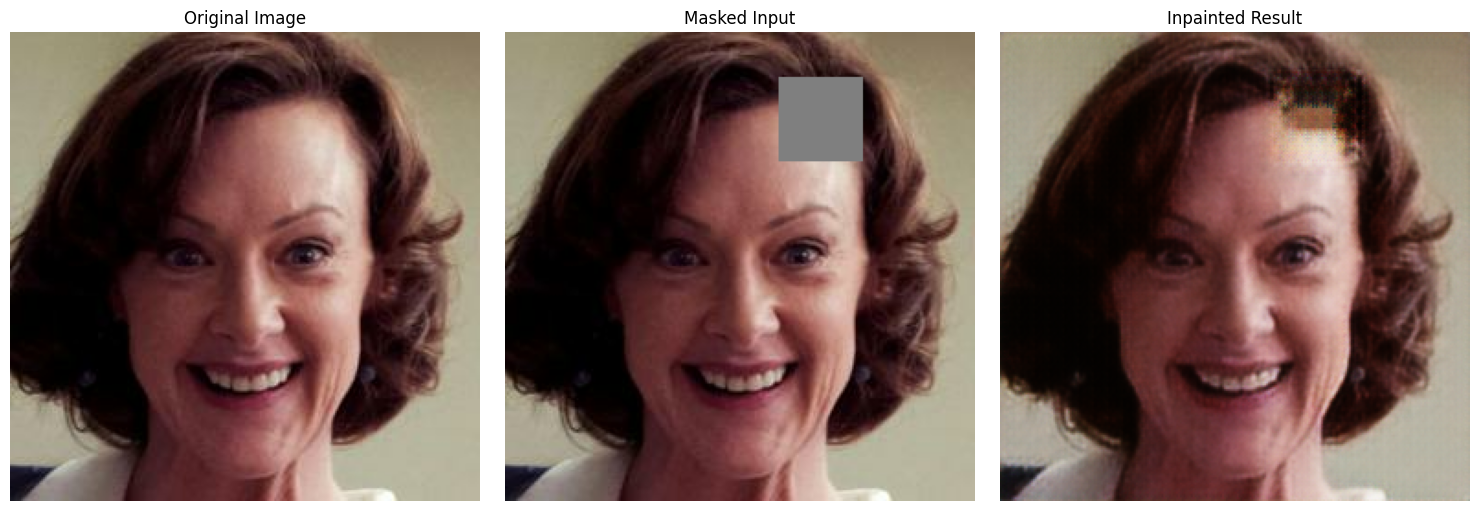


Epoch 73/100 


Epoch 73: 100%|██████████| 125/125 [11:35<00:00,  5.56s/it]


Generator loss: 3.8449 (best: 3.8951)
Discriminator loss: 0.4642
G/D ratio: 8.28

Epoch 74/100 


Epoch 74: 100%|██████████| 125/125 [12:22<00:00,  5.94s/it]


Generator loss: 3.7907 (best: 3.7907)
Discriminator loss: 0.4523
G/D ratio: 8.38


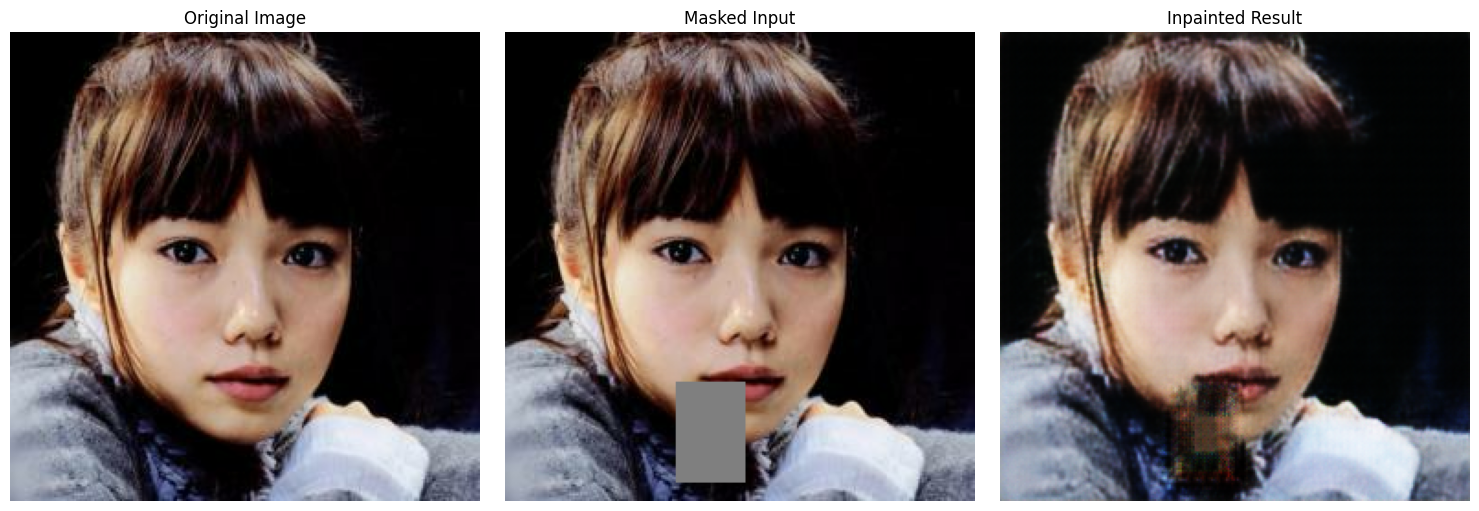


Epoch 75/100 


Epoch 75: 100%|██████████| 125/125 [12:22<00:00,  5.94s/it]


Generator loss: 3.9255 (best: 3.7907)
Discriminator loss: 0.4435
G/D ratio: 8.85

Epoch 76/100 


Epoch 76: 100%|██████████| 125/125 [12:22<00:00,  5.94s/it]


Generator loss: 3.8795 (best: 3.7907)
Discriminator loss: 0.4664
G/D ratio: 8.32


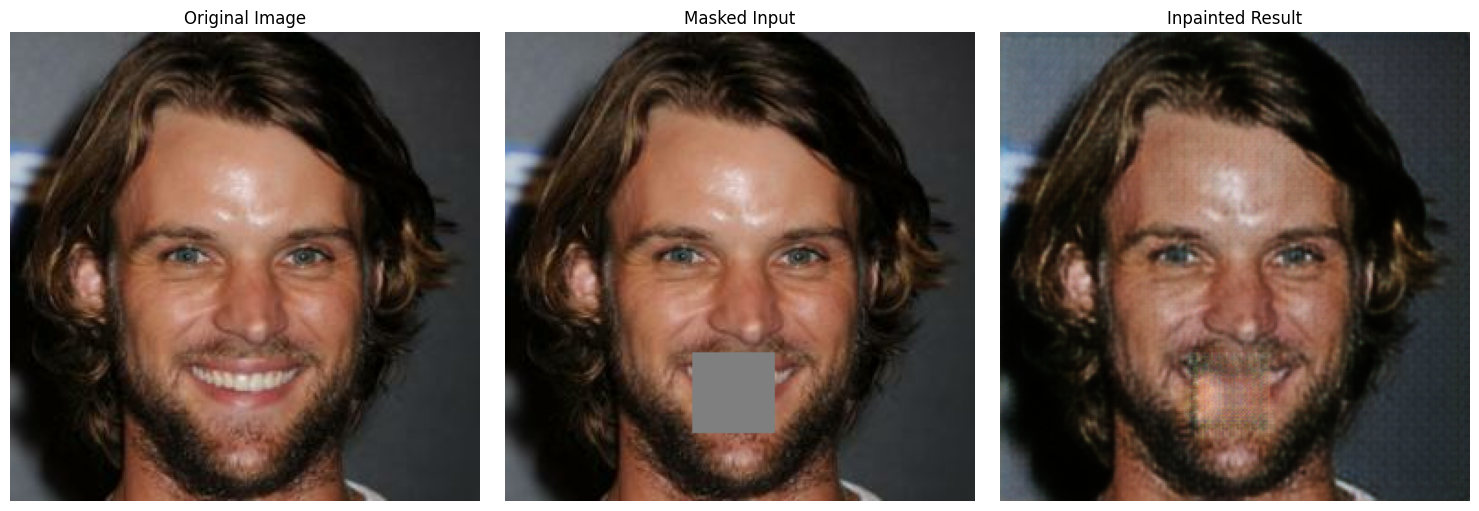


Epoch 77/100 


Epoch 77: 100%|██████████| 125/125 [12:22<00:00,  5.94s/it]


Generator loss: 3.9118 (best: 3.7907)
Discriminator loss: 0.4728
G/D ratio: 8.27

Epoch 78/100 


Epoch 78: 100%|██████████| 125/125 [11:38<00:00,  5.58s/it]


Generator loss: 3.9784 (best: 3.7907)
Discriminator loss: 0.4409
G/D ratio: 9.02


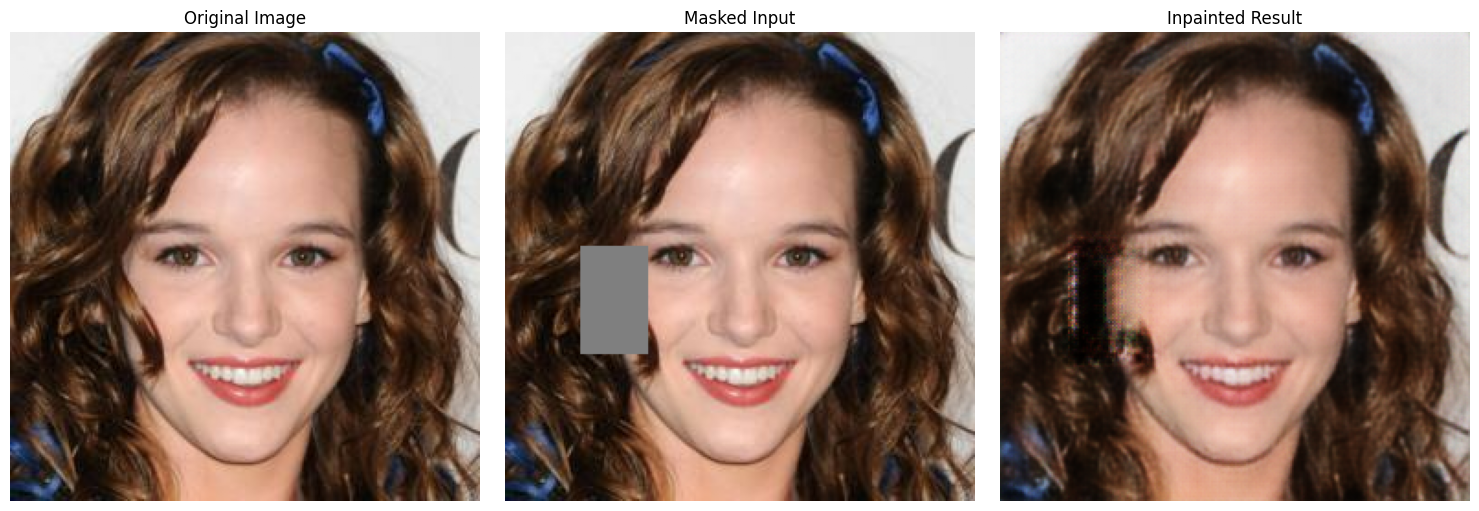


Epoch 79/100 


Epoch 79: 100%|██████████| 125/125 [12:22<00:00,  5.94s/it]


Generator loss: 3.9408 (best: 3.7907)
Discriminator loss: 0.4560
G/D ratio: 8.64

Epoch 80/100 


Epoch 80: 100%|██████████| 125/125 [12:22<00:00,  5.94s/it]


Generator loss: 3.9227 (best: 3.7907)
Discriminator loss: 0.4472
G/D ratio: 8.77


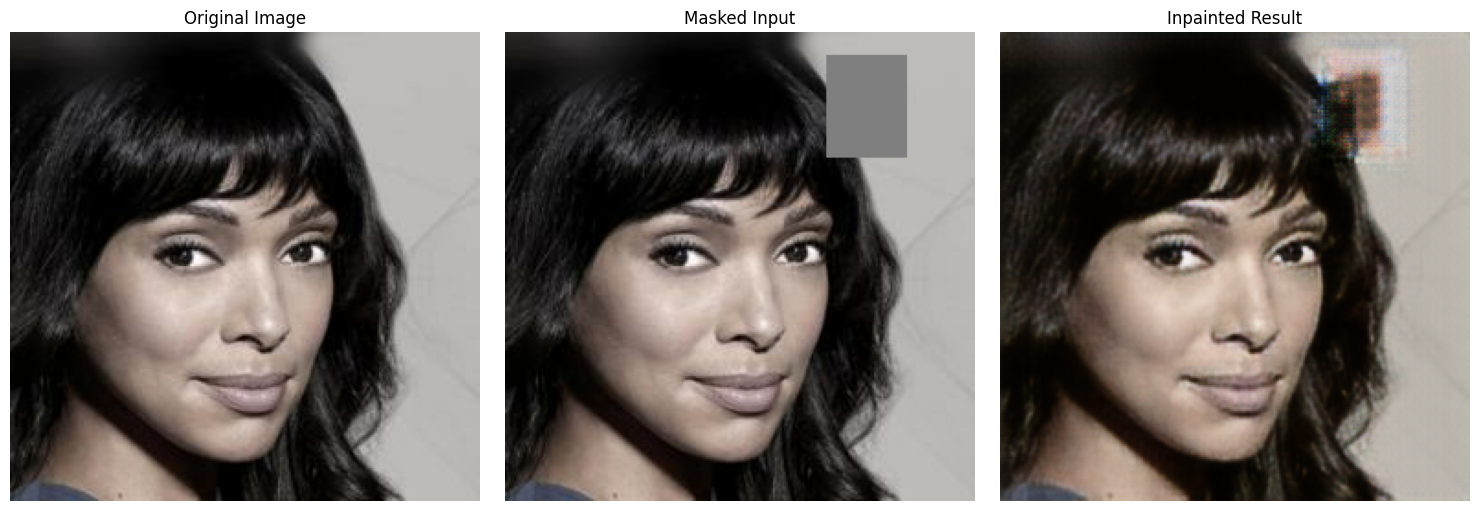


Epoch 81/100 


Epoch 81: 100%|██████████| 125/125 [11:49<00:00,  5.67s/it]


Generator loss: 4.0285 (best: 3.7907)
Discriminator loss: 0.4139
G/D ratio: 9.73

Epoch 82/100 


Epoch 82: 100%|██████████| 125/125 [12:22<00:00,  5.94s/it]


Generator loss: 3.9567 (best: 3.7907)
Discriminator loss: 0.4363
G/D ratio: 9.07


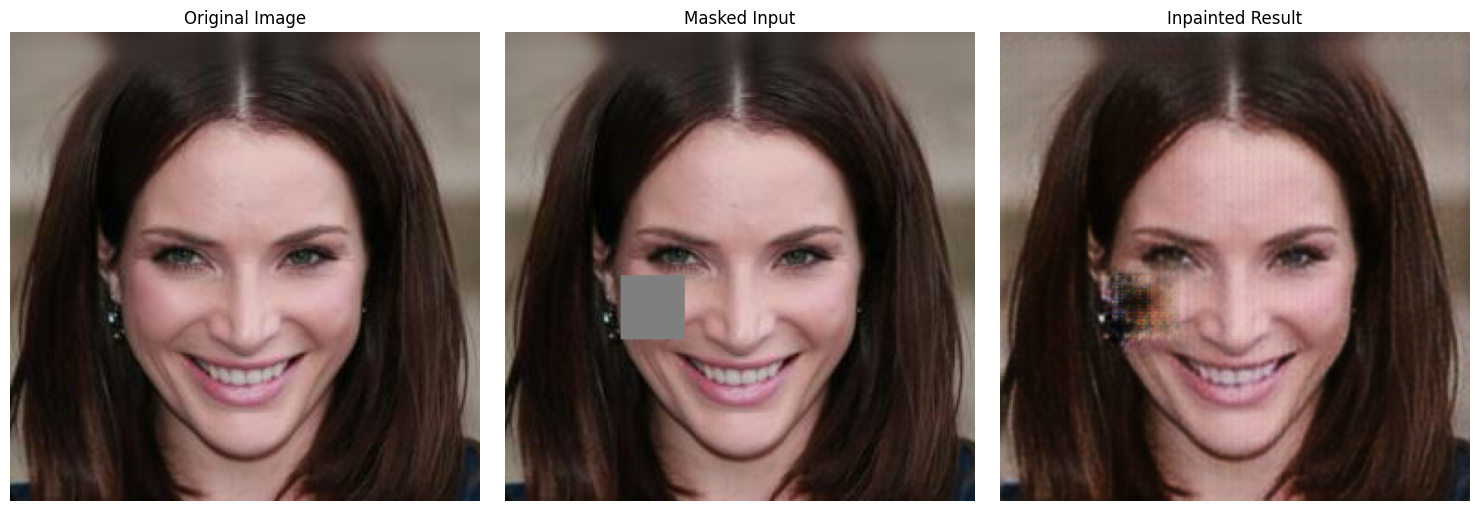


Epoch 83/100 


Epoch 83: 100%|██████████| 125/125 [11:22<00:00,  5.46s/it]


Generator loss: 4.0242 (best: 3.7907)
Discriminator loss: 0.4442
G/D ratio: 9.06

Epoch 84/100 


Epoch 84: 100%|██████████| 125/125 [12:23<00:00,  5.95s/it]



Early stopping triggered!

Saved final model to: /content/drive/MyDrive/AAI_Miniproject_UK/generator_ep100.h5


In [ ]:

# @title Complete Training Loop with Visualization and Resume Support
import matplotlib.pyplot as plt

def visualize_progress(batch):
    """Display training progress with sample predictions"""
    real, mask, masked = batch
    pred = generator([masked[:1], mask[:1]], training=False)

    plt.figure(figsize=(15, 5))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(real[0].numpy() * 0.5 + 0.5)
    plt.title("Original Image")
    plt.axis('off')

    # Masked input
    plt.subplot(1, 3, 2)
    plt.imshow(masked[0].numpy() * 0.5 + 0.5)
    plt.title("Masked Input")
    plt.axis('off')

    # Inpainted result
    plt.subplot(1, 3, 3)
    plt.imshow(pred[0].numpy() * 0.5 + 0.5)
    plt.title("Inpainted Result")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
@tf.function
def train_step(real_images, masks, masked_images):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate images
        generated_images = generator([masked_images, masks], training=True)

        # Discriminator outputs
        real_output = discriminator([real_images, masks], training=True)
        fake_output = discriminator([generated_images, masks], training=True)

        # Losses
        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        disc_loss = cross_entropy(tf.concat([tf.ones_like(real_output),
                                           tf.zeros_like(fake_output)], axis=0),
                                tf.concat([real_output, fake_output], axis=0))

        # Add L1 reconstruction loss
        l1_loss = tf.reduce_mean(tf.abs(real_images - generated_images))
        gen_loss += 50 * l1_loss  # Weighted sum

    # Apply gradients with clipping (NEW)
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen_gradients = [tf.clip_by_norm(g, 1.0) for g in gen_gradients]  # Gradient clipping
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    disc_gradients = [tf.clip_by_norm(d, 1.0) for d in disc_gradients]

    g_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

def train(dataset, initial_epoch=0):  # CHANGED: Added initial_epoch parameter
    global best_loss, wait

    # NEW: Load best loss from checkpoint if resuming
    if initial_epoch > 0:
        try:
            best_ckpt = os.path.join(checkpoint_dir, "best")
            if os.path.exists(best_ckpt+".index"):
                best_loss = float(best_ckpt.split('_gl')[-1].split('_')[0])
                print(f"Resumed best loss: {best_loss:.4f}")
        except:
            pass

    for epoch in range(initial_epoch, EPOCHS):  # CHANGED: Start from initial_epoch
        print(f"\nEpoch {epoch+1}/{EPOCHS} {'(resumed)' if epoch == initial_epoch and initial_epoch > 0 else ''}")

        gen_loss_avg = tf.keras.metrics.Mean()
        disc_loss_avg = tf.keras.metrics.Mean()

        for batch in tqdm(dataset.take(STEPS_PER_EPOCH),
                         total=STEPS_PER_EPOCH,
                         desc=f"Epoch {epoch+1}"):
            gl, dl = train_step(*batch)
            gen_loss_avg.update_state(gl)
            disc_loss_avg.update_state(dl)

        current_gen_loss = gen_loss_avg.result()
        current_disc_loss = disc_loss_avg.result()

        # NEW: Improved checkpoint naming with loss values
        if (epoch + 1) % 2 == 0:
            ckpt_name = f"ckpt_ep{epoch+1}_gl{current_gen_loss:.4f}_dl{current_disc_loss:.4f}"
            checkpoint.save(file_prefix=os.path.join(checkpoint_dir, ckpt_name))

            # Save "best" checkpoint separately
            if current_gen_loss < best_loss:
                best_loss = current_gen_loss
                wait = 0
                checkpoint.save(file_prefix=os.path.join(checkpoint_dir, "best"))
            else:
                wait += 1
                if wait >= patience:
                    print("\nEarly stopping triggered!")
                    break

        # NEW: Enhanced progress display
        print(f"Generator loss: {current_gen_loss:.4f} (best: {best_loss:.4f})")
        print(f"Discriminator loss: {current_disc_loss:.4f}")
        print(f"G/D ratio: {current_gen_loss/current_disc_loss:.2f}")

        if (epoch + 1) % 2 == 0:
            visualize_progress(next(iter(dataset)))

# NEW: Modified training start with initial_epoch
initial_epoch = 70  # SET THIS TO YOUR LAST COMPLETED EPOCH
train(dataset, initial_epoch=initial_epoch)

# Save final model with epoch number (NEW)
final_model_path = os.path.join(MODEL_PATH, f'generator_ep{EPOCHS}.h5')
generator.save(final_model_path)
print(f"\nSaved final model to: {final_model_path}")

Saving 00083.jpg to 00083.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


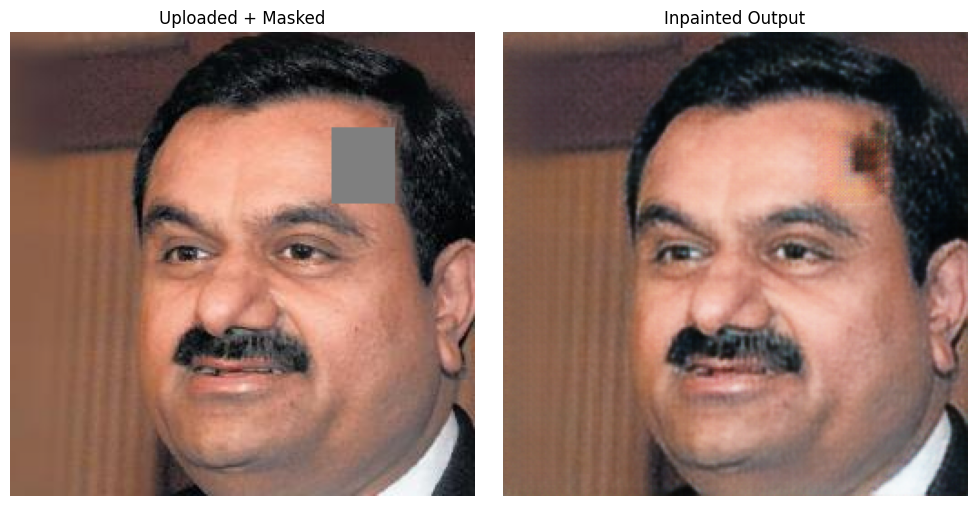

In [ ]:
from google.colab import files

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ⬇️ Load final trained generator
from tensorflow.keras.models import load_model
generator = build_generator()  # Make sure your architecture is loaded
generator.load_weights('//ADD DRIVE PATH WHERE MODEL IS SAVED//')  # 🔁 Adjust path if needed

# 🔧 Utility Functions
def preprocess_image(image_path, img_size=IMG_SIZE):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = (img / 127.5) - 1  # Normalize to [-1, 1]
    return img.astype(np.float32)

def apply_random_rect_mask(img):
    h, w, _ = img.shape
    mask = np.ones_like(img, dtype=np.float32)

    # Apply random rectangular mask (same logic as training)
    mask_height = np.random.randint(32, 65)
    mask_width = np.random.randint(32, 65)
    x = np.random.randint(0, w - mask_width)
    y = np.random.randint(0, h - mask_height)
    mask[y:y+mask_height, x:x+mask_width, :] = 0

    masked_img = img * mask
    return masked_img, mask

# ⬆️ Upload your image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
original_img = preprocess_image(image_path)
masked_img, mask = apply_random_rect_mask(original_img)

# Expand dims for batch processing
masked_input = np.expand_dims(masked_img, axis=0)
mask_input = np.expand_dims(mask, axis=0)

# ⚙️ Generate inpainted result
inpainted_output = generator.predict([masked_input, mask_input])[0]
inpainted_output = (inpainted_output + 1) / 2  # Unnormalize for display
masked_img_disp = (masked_img + 1) / 2  # Unnormalize for display

# 🎨 Visualize
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(masked_img_disp)
plt.title("Uploaded + Masked")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inpainted_output)
plt.title("Inpainted Output")
plt.axis('off')

plt.tight_layout()
plt.show()
